In [1]:
from google.colab import files
import pandas as pd
uploaded = files.upload()

Saving 1k_stories_100_genre.csv to 1k_stories_100_genre.csv


In [28]:
df = pd.read_csv("1k_stories_100_genre.csv")

In [29]:
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
display(df.head(5))

Dataset shape: (1000, 4)
Columns: ['id', 'title', 'story', 'genre']


,id,title,story,genre
0,457580,The Chronicles of the Cosmic Rift,"In the year 2250, Earth had made significant s...",Science Fiction
1,297904,Eldoria's Enchanted Whispers,"In a land far away, where the sun shone bright...",Fantasy
2,620436,Echoes of Whispered Shadows,"Once upon a time, in a small, tranquil town ca...",Mystery
3,634687,Emerald Amulet Chronicles Revealed,"Once upon a time in the 16th century, a small ...",Historical Adventure
4,513427,The Shadows of St. Augustine,In the sun-drenched coastal city of St. August...,Thriller


In [31]:
import matplotlib.pyplot as plt

genre_counts = df['genre'].value_counts()

In [32]:
genre_counts

,count
genre,
Historical Adventure,20
Fantasy,10
Science Fiction,10
Mystery,10
Thriller,10
...,...
Space Exploration,10
Steampunk Fantasy,10
Noir Comedy,10


In [ ]:
#We use the most common 15

In [33]:
TOP_GENERES = genre_counts[:15]

In [34]:
TOP_GENERES = TOP_GENERES.index.tolist()

In [35]:
TOP_GENERES

['Historical Adventure',
 'Fantasy',
 'Science Fiction',
 'Mystery',
 'Thriller',
 'Historical Fiction',
 'Adventure',
 'Horror',
 'Comedy',
 'Crime',
 'Dystopian',
 'Cyberpunk',
 'Steampunk',
 'Post-Apocalyptic',
 'Fairy Tale']

In [37]:
top_counts = genre_counts[TOP_GENERES]

In [39]:
top_counts

,count
genre,
Historical Adventure,20
Fantasy,10
Science Fiction,10
Mystery,10
Thriller,10
Historical Fiction,10
Adventure,10
Horror,10
Comedy,10


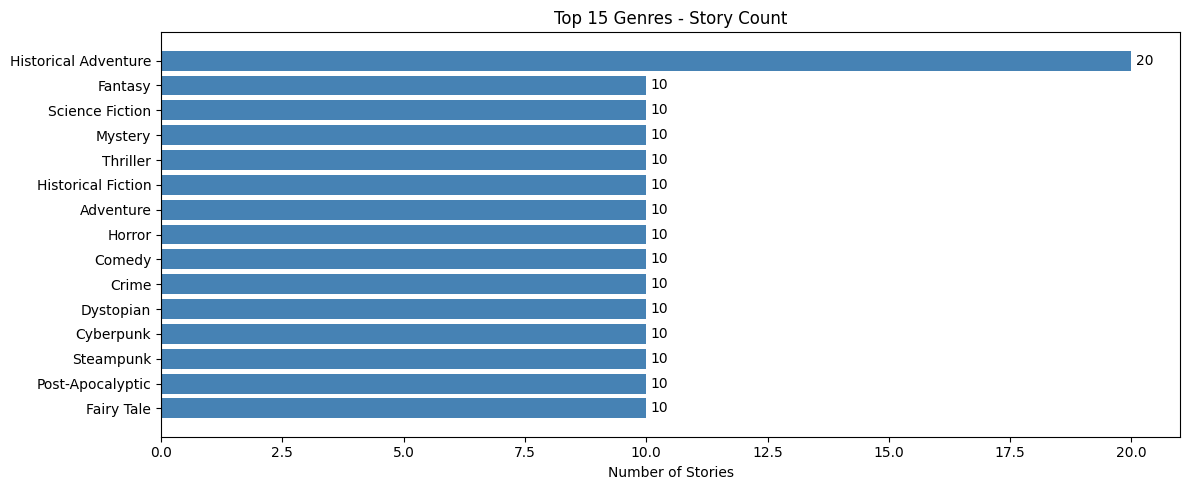


Total stories in top 15 genres: 160


In [40]:
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_counts.index[::-1], top_counts.values[::-1], color='steelblue')
ax.bar_label(bars, padding=3)
ax.set_xlabel('Number of Stories')
ax.set_title('Top 15 Genres - Story Count')
plt.tight_layout()
plt.show()

print(f"\nTotal stories in top 15 genres: {top_counts.sum()}")

In [53]:
few_shot_examples = {}
for genre in TOP_GENERES:
    subset = df[df['genre'] == genre].reset_index(drop=True)
    few_shot_examples[genre] = []
    for i in range(min(2, len(subset))):
        row = subset.iloc[i]
        few_shot_examples[genre].append({
            'title': row['title'],
            'snippet': row['story'][:400]
        })

print(f"few_shot_examples built for {len(few_shot_examples)} genres:")
for g, exs in few_shot_examples.items():
    print(f"  {g}: {len(exs)} examples")


few_shot_examples built for 15 genres:
  Historical Adventure: 2 examples
  Fantasy: 2 examples
  Science Fiction: 2 examples
  Mystery: 2 examples
  Thriller: 2 examples
  Historical Fiction: 2 examples
  Adventure: 2 examples
  Horror: 2 examples
  Comedy: 2 examples
  Crime: 2 examples
  Dystopian: 2 examples
  Cyberpunk: 2 examples
  Steampunk: 2 examples
  Post-Apocalyptic: 2 examples
  Fairy Tale: 2 examples


In [46]:
from transformers import pipeline

In [48]:
from huggingface_hub import login

login()

In [49]:
classifier = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=-1
)

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [54]:
GENRE_HINT_MAP = {
    'Historical Adventure': 'historical adventure set in past centuries with quests and kingdoms',
    'Science Fiction':      'science fiction with space travel, futuristic technology and alien worlds',
    'Fantasy':              'fantasy with magic, enchanted forests and mythical creatures',
    'Mystery':              'mystery with detectives, secrets and unsolved crimes',
    'Thriller':             'thriller with danger, betrayal and high-stakes tension',
    'Horror':               'horror with ghosts, haunted places and terrifying events',
    'Comedy':               'comedy with humorous characters and funny situations',
    'Crime':                'crime story with criminals, investigations and urban danger',
    'Dystopian':            'dystopian society with oppressive regimes and ruined civilizations',
    'Cyberpunk':            'cyberpunk with neon cities, hacking and human-machine fusion',
    'Post-Apocalyptic':     'post-apocalyptic survival after the collapse of civilization',
    'Fairy Tale':           'fairy tale with enchanted kingdoms, magic spells and princesses',
    'Adventure':            'adventure with exploration, brave heroes and unknown lands',
    'War':                  'war story with battles, soldiers and military conflict',
    'Superhero':            'superhero story with extraordinary powers and saving the world',
    'Romance':              'romance story with love, relationships and emotional connection',
    'Western':              'western story with cowboys, frontier towns and wild west settings',
    'Steampunk':            'steampunk with Victorian-era technology and mechanical inventions',
    'Mythology':            'mythology with gods, ancient legends and heroic epics',
    'Spy':                  'spy thriller with secret agents, espionage and covert missions',
    'Supernatural':         'supernatural story with paranormal events and unexplained phenomena',
    'Psychological':        'psychological story exploring the human mind and mental states',
    'Satire':               'satirical story mocking society, politics or human behavior',
    'Sports':               'sports story with athletes, competitions and team spirit',
}

In [55]:
GENRE_HINTS = {}
for g in TOP_GENERES:
    GENRE_HINTS[g] = GENRE_HINT_MAP.get(g, f'{g.lower()} story')

In [56]:
GENRE_HINTS.keys()

dict_keys(['Historical Adventure', 'Fantasy', 'Science Fiction', 'Mystery', 'Thriller', 'Historical Fiction', 'Adventure', 'Horror', 'Comedy', 'Crime', 'Dystopian', 'Cyberpunk', 'Steampunk', 'Post-Apocalyptic', 'Fairy Tale'])

In [57]:
candidate_labels = [GENRE_HINTS[g] for g in TOP_GENERES]
label_to_genre   = {v: k for k, v in GENRE_HINTS.items()}

In [60]:
import textwrap

In [61]:
def build_few_shot_prompt(query_story: str, n_shots_per_genre: int = 1) -> str:
    """
    Build a few-shot prompt for genre classification.

    Parameters

    query_story : str
        The new story (or excerpt) to classify.
    n_shots_per_genre : int
        How many examples per genre to include (1 or 2).
    """
    lines = []
    lines.append("You are an expert literary genre classifier.")
    lines.append("Given a story excerpt, respond with ONLY the genre name – nothing else.")
    lines.append(f"Valid genres: {', '.join(TOP_GENERES)}")
    lines.append("")
    lines.append("=== EXAMPLES ===")

    for genre, examples in few_shot_examples.items():
        for ex in examples[:n_shots_per_genre]:
            lines.append(f"Story: {ex['snippet'][:300]}")
            lines.append(f"Genre: {genre}")
            lines.append("")

    lines.append("=== CLASSIFY ===")
    lines.append(f"Story: {query_story[:500]}")
    lines.append("Genre:")

    return "\n".join(lines)

sample_prompt = build_few_shot_prompt("A knight rides through a fog-covered forest...", n_shots_per_genre=1)
print(f"Prompt length (1 shot/genre): {len(sample_prompt)} chars / ~{len(sample_prompt)//4} tokens")
print()
print(textwrap.fill(sample_prompt[:600], width=90), "\n[... truncated ...]")

Prompt length (1 shot/genre): 5318 chars / ~1329 tokens

You are an expert literary genre classifier. Given a story excerpt, respond with ONLY the
genre name – nothing else. Valid genres: Historical Adventure, Fantasy, Science Fiction,
Mystery, Thriller, Historical Fiction, Adventure, Horror, Comedy, Crime, Dystopian,
Cyberpunk, Steampunk, Post-Apocalyptic, Fairy Tale  === EXAMPLES === Story: Once upon a
time in the 16th century, a small village nestled in the heart of the English countryside,
far from the maddening crowd. The villagers, led by the wise and benevolent Mayor Thomas,
lived in harmony, and their days were filled with laughter and joy. 
[... truncated ...]


In [62]:
def classify_story(story_text: str, verbose: bool = True) -> str:
    """
    Classify a story using zero-shot NLI (facebook/bart-large-mnli).
    Runs locally.
    """
    result = classifier(
        story_text[:1000],
        candidate_labels=candidate_labels,
        hypothesis_template='This story is a {}.',
        multi_label=False
    )

    top_label = result['labels'][0]
    top_score = result['scores'][0]
    predicted_genre = label_to_genre.get(top_label, top_label)

    if verbose:
        print(f'Predicted genre : {predicted_genre}')
        print(f'Confidence      : {top_score:.3f}')
        print()
        print('All scores:')
        for lbl, sc in zip(result['labels'], result['scores']):
            genre = label_to_genre.get(lbl, lbl)
            bar = '█' * int(sc * 30)
            print(f'  {genre:<25} {sc:.3f} {bar}')

    return predicted_genre


# ── Test ──────────────────────────────────────────────────────────────────────
test_story = """
In the neon-soaked alleyways of Neo-Shanghai, where corporate drones
flew surveillance patterns and black-market neural chips changed hands
for untraceable crypto, Mira jacked into the grid one last time.
Her augmented eyes scanned the firewall – a shimmering wall of violet code.
"""

result = classify_story(test_story)


Predicted genre : Cyberpunk
Confidence      : 0.288

All scores:
  Cyberpunk                 0.288 ████████
  Crime                     0.243 ███████
  Comedy                    0.088 ██
  Thriller                  0.071 ██
  Mystery                   0.063 █
  Adventure                 0.046 █
  Science Fiction           0.041 █
  Steampunk                 0.035 █
  Horror                    0.034 █
  Historical Fiction        0.026 
  Dystopian                 0.019 
  Post-Apocalyptic          0.014 
  Historical Adventure      0.013 
  Fairy Tale                0.010 
  Fantasy                   0.008 


In [66]:
# held-out test set (stories at index 2 and 3 per genre)
test_rows = []
for genre in TOP_GENERES:
    subset = df[df['genre'] == genre].reset_index(drop=True)
    for i in [2, 3]:
        if i < len(subset):
            test_rows.append({
                'title': subset.iloc[i]['title'],
                'story': subset.iloc[i]['story'],
                'true_genre': genre
            })

test_df = pd.DataFrame(test_rows)
print(f"Test set: {len(test_df)} stories across {test_df['true_genre'].nunique()} genres")
display(test_df[['title', 'true_genre']].head(10))


Test set: 30 stories across 15 genres


,title,true_genre
0,The Chronicles of the Braveheart Pirates,Historical Adventure
1,The Chronicles of the Golden Phoenix,Historical Adventure
2,The Chronicles of Elaria: The Realm of Shadows,Fantasy
3,Enchanted Forest Chronicles Unveiled,Fantasy
4,The Quantum Chronicles: The Quest for the Lost...,Science Fiction
5,The Interstellar Odyssey,Science Fiction
6,The Curious Case of the Vanishing Villain,Mystery
7,The Mystery of the Lost Library,Mystery
8,Veil of Betrayal,Thriller
9,The Shadow of Justice,Thriller


In [67]:
results = []
for _, row in test_df.iterrows():
    pred = classify_story(row['story'], verbose=False)
    correct = pred.strip().lower() == row['true_genre'].strip().lower()
    results.append({'title': row['title'],
                    'true_genre': row['true_genre'],
                    'predicted': pred,
                    'correct': correct})
    print(f"  {'CORRECT' if correct else 'INCORRECT'}  True: {row['true_genre']:<25} | Pred: {pred}")

results_df = pd.DataFrame(results)


  INCORRECT  True: Historical Adventure      | Pred: Adventure
  CORRECT  True: Historical Adventure      | Pred: Historical Adventure
  CORRECT  True: Fantasy                   | Pred: Fantasy
  CORRECT  True: Fantasy                   | Pred: Fantasy
  CORRECT  True: Science Fiction           | Pred: Science Fiction
  CORRECT  True: Science Fiction           | Pred: Science Fiction
  CORRECT  True: Mystery                   | Pred: Mystery
  CORRECT  True: Mystery                   | Pred: Mystery
  INCORRECT  True: Thriller                  | Pred: Crime
  INCORRECT  True: Thriller                  | Pred: Crime
  INCORRECT  True: Historical Fiction        | Pred: Historical Adventure
  INCORRECT  True: Historical Fiction        | Pred: Historical Adventure
  CORRECT  True: Adventure                 | Pred: Adventure
  CORRECT  True: Adventure                 | Pred: Adventure
  INCORRECT  True: Horror                    | Pred: Mystery
  INCORRECT  True: Horror                    |

In [68]:
accuracy = results_df['correct'].mean()
print(f"\nAccuracy: {accuracy:.1%} ({results_df['correct'].sum()}/{len(results_df)})")


Accuracy: 63.3% (19/30)


In [69]:
sample_genre = TOP_GENERES[0]
sample = df[df['genre'] == sample_genre].iloc[4]['story']

print(f'True genre: {sample_genre}')
print()
print('Short excerpt (200 chars)')
classify_story(sample[:200])

print()
print('Full excerpt (1000 chars)')
classify_story(sample[:1000])


True genre: Historical Adventure

Short excerpt (200 chars)
Predicted genre : Adventure
Confidence      : 0.473

All scores:
  Adventure                 0.473 ██████████████
  Fantasy                   0.108 ███
  Historical Fiction        0.077 ██
  Steampunk                 0.071 ██
  Historical Adventure      0.049 █
  Comedy                    0.047 █
  Fairy Tale                0.027 
  Horror                    0.023 
  Thriller                  0.022 
  Crime                     0.021 
  Mystery                   0.021 
  Post-Apocalyptic          0.019 
  Science Fiction           0.017 
  Cyberpunk                 0.014 
  Dystopian                 0.011 

Full excerpt (1000 chars)
Predicted genre : Adventure
Confidence      : 0.240

All scores:
  Adventure                 0.240 ███████
  Steampunk                 0.142 ████
  Fantasy                   0.121 ███
  Historical Fiction        0.100 ██
  Comedy                    0.075 ██
  Mystery                   0.056 █
  Hist

'Adventure'

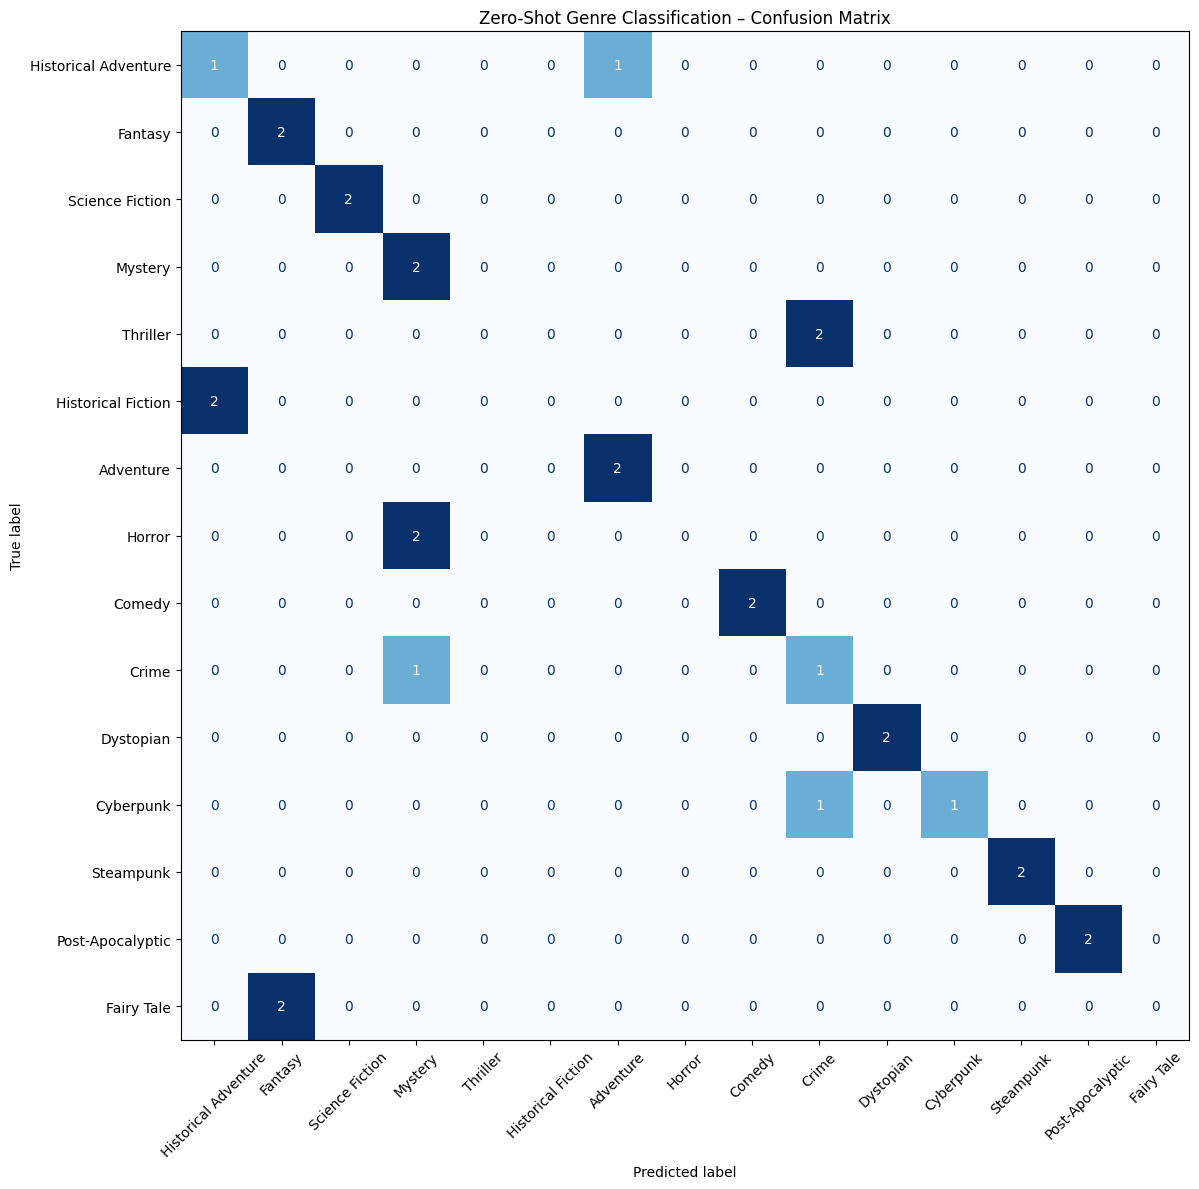

In [70]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

labels = TOP_GENERES
cm = confusion_matrix(results_df['true_genre'], results_df['predicted'], labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(14, 12))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap='Blues')
ax.set_title('Zero-Shot Genre Classification – Confusion Matrix')
plt.tight_layout()
plt.show()
